In [ ]:
import pandas as pd

# Load the dataset
file_path = 'gold_prices_1947_2026_INR.csv'
df = pd.read_csv(file_path)

# Display basic info and head
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   80 non-null     int64  
 1   Gold_Price_USD_per_oz  80 non-null     float64
 2   USD_INR_Rate           80 non-null     float64
 3   Gold_Price_INR_per_oz  80 non-null     float64
 4   Notes                  80 non-null     object 
dtypes: float64(3), int64(1), object(1)
memory usage: 3.3+ KB
None
   Year  Gold_Price_USD_per_oz  USD_INR_Rate  Gold_Price_INR_per_oz  \
0  1947                  43.00          3.30                 141.90   
1  1948                  42.00          3.30                 138.60   
2  1949                  40.50          4.76                 192.78   
3  1950                  40.25          4.76                 191.59   
4  1951                  40.00          4.76                 190.40   

                                        

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# 1. Load and Prepare
df = pd.read_csv('gold_prices_1947_2026_INR.csv')
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

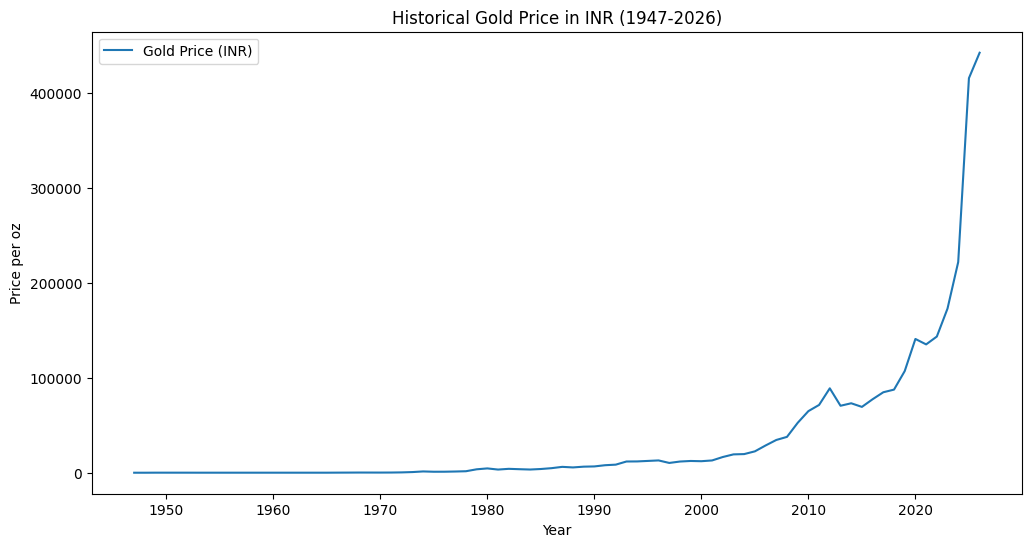

In [ ]:
# 2. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df['Gold_Price_INR_per_oz'], label='Gold Price (INR)')
plt.title('Historical Gold Price in INR (1947-2026)')
plt.xlabel('Year')
plt.ylabel('Price per oz')
plt.legend()
plt.savefig('gold_price_trend.png')

In [ ]:
# 3. Stationarity Test (ADF)
result = adfuller(df['Gold_Price_INR_per_oz'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: 20.05747280265639
p-value: 1.0


In [ ]:
# 4. Feature Engineering: Lags
df['Lag_1'] = df['Gold_Price_INR_per_oz'].shift(1)
df['Lag_2'] = df['Gold_Price_INR_per_oz'].shift(2)
df['MA_5'] = df['Gold_Price_INR_per_oz'].rolling(window=5).mean()
df.dropna(inplace=True)

In [ ]:
# 5. Train-Test Split (Time-based)
train = df[df.index.year <= 2015]
test = df[df.index.year > 2015]

In [ ]:
# --- MODEL 1: Baseline (Naive) ---
test_naive = test.copy()
test_naive['Pred_Naive'] = df['Gold_Price_INR_per_oz'].shift(1).loc[test.index]

In [ ]:
# --- MODEL 2: Linear Regression ---
X_train = train[['Lag_1', 'Lag_2', 'USD_INR_Rate']]
y_train = train['Gold_Price_INR_per_oz']
X_test = test[['Lag_1', 'Lag_2', 'USD_INR_Rate']]
y_test = test['Gold_Price_INR_per_oz']

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
test_lr = lr_model.predict(X_test)

In [ ]:
# --- MODEL 3: ARIMA ---
# We use the raw series for ARIMA as it handles differencing internally (d parameter)
history = [x for x in train['Gold_Price_INR_per_oz']]
predictions_arima = []
for t in range(len(test)):
    model = ARIMA(history, order=(1,1,1)) # p,d,q
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions_arima.append(yhat)
    history.append(test['Gold_Price_INR_per_oz'].iloc[t])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
# 6. Evaluation
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2: {r2:.4f}')
    return mae, rmse, r2

evaluate(y_test, test_naive['Pred_Naive'], 'Naive Baseline')
evaluate(y_test, test_lr, 'Linear Regression')
evaluate(y_test, predictions_arima, 'ARIMA')

--- Naive Baseline ---
MAE: 34908.38
RMSE: 62628.48
R2: 0.7367
--- Linear Regression ---
MAE: 33054.60
RMSE: 61690.97
R2: 0.7445
--- ARIMA ---
MAE: 45001.08
RMSE: 76450.87
R2: 0.6076


(45001.08480873477, np.float64(76450.87049868159), 0.6076431675831568)

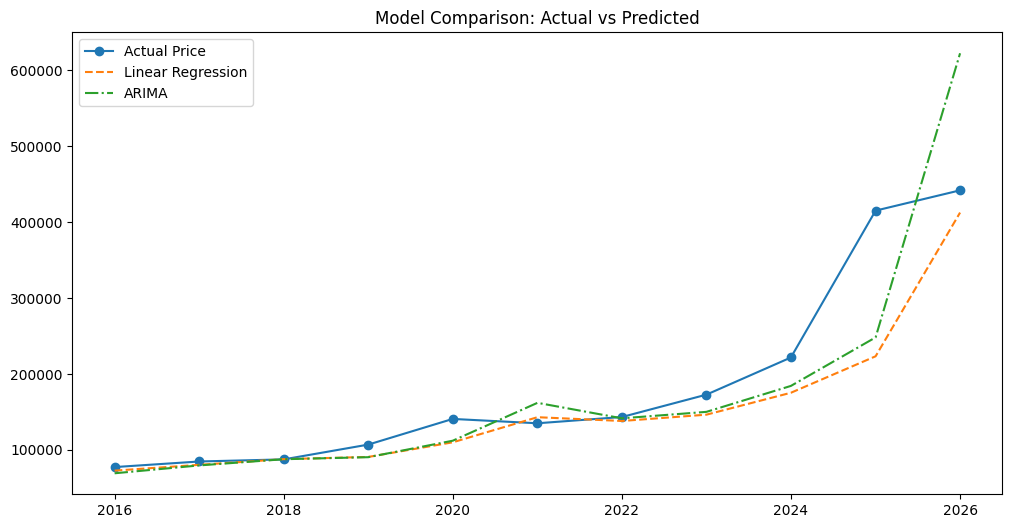

In [ ]:
# 7. Final Plot
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label='Actual Price', marker='o')
plt.plot(test.index, test_lr, label='Linear Regression', linestyle='--')
plt.plot(test.index, predictions_arima, label='ARIMA', linestyle='-.')
plt.title('Model Comparison: Actual vs Predicted')
plt.legend()
plt.savefig('model_comparison.png')

In [ ]:
#Phase 1: Data Acquisition & Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. Load Data
df = pd.read_csv('gold_prices_1947_2026_INR.csv')
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

In [ ]:
# 2. Test for Stationarity (ADF Test)
# Gold prices usually have a trend and are NOT stationary.
result = adfuller(df['Gold_Price_INR_per_oz'])
print(f'ADF P-value: {result[1]}')
# If p-value > 0.05, the data is non-stationary.

ADF P-value: 1.0


In [ ]:
#Phase 2: Feature Engineering

In [ ]:
# Create Lagged features (Previous 1 and 2 years)
df['Lag_1'] = df['Gold_Price_INR_per_oz'].shift(1)
df['Lag_2'] = df['Gold_Price_INR_per_oz'].shift(2)

# Create a 5-year Rolling Average
df['MA_5'] = df['Gold_Price_INR_per_oz'].rolling(window=5).mean()

# Drop rows with NaN values created by shifting
df.dropna(inplace=True)

In [ ]:
#Phase 3: Model Implementation
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA

# Split data: Training (before 2015), Testing (2015-2026)
train = df[df.index.year <= 2015]
test = df[df.index.year > 2015]

# --- MODEL 1: Linear Regression (The Engineer) ---
X_train = train[['Lag_1', 'Lag_2', 'USD_INR_Rate']]
y_train = train['Gold_Price_INR_per_oz']
X_test = test[['Lag_1', 'Lag_2', 'USD_INR_Rate']]
y_test = test['Gold_Price_INR_per_oz']

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
preds_lr = lr_model.predict(X_test)

In [ ]:
# --- MODEL 2: ARIMA (The Statistician) ---
# We use a rolling forecast for ARIMA
history = [x for x in train['Gold_Price_INR_per_oz']]
preds_arima = []
for t in range(len(test)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    preds_arima.append(model_fit.forecast()[0])
    history.append(y_test.iloc[t])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
#Phase 4: Evaluation & Result Visualization
from sklearn.metrics import mean_absolute_error, r2_score

def print_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> MAE: {mae:.2f}, R2 Score: {r2:.4f}")

# Compare Models
print_metrics(y_test, test['Lag_1'], "Naive Baseline")
print_metrics(y_test, preds_lr, "Linear Regression")
print_metrics(y_test, preds_arima, "ARIMA")

Naive Baseline -> MAE: 34908.38, R2 Score: 0.7367
Linear Regression -> MAE: 33054.60, R2 Score: 0.7445
ARIMA -> MAE: 45001.08, R2 Score: 0.6076
